# ORIE 4580/5580/5581 Assignment 6

#### Students: London Brown (LMB395) and Katie Zelvin (KLZ24)

### Github link: [example Github link](https://github.com/SidBanerjee/ORIE4580-Simulation/blob/main/Notebooks/Unit0-Intro_Demos.ipynb)


### Instructions


* Due Thursday, November 6, at 11.59pm on Gradescope.
* Assignment .ipynb files available for download on [Canvas](https://canvas.cornell.edu/courses/80773#:~:text=Assignments-,Assignments,-Assignments%20module%20publish). Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Ideally do assignments in groups of 2, and submit a single pdf with both names
* Please show your work and clearly mark your answers.
* You can use any code fragments given in class, found online (for example, on StackOverflow), or generated via Gemini/Claude/ChatGPT (you are encouraged to use these for first drafts) **with proper referencing**.
* You can also discuss with others (again, please reference them if you do so); but you must write your final answers on your own as a team.



### Essential reading

The chapters on [Poisson Process](https://canvas.cornell.edu/courses/80773/modules/items/3269525), [DTMCs](https://canvas.cornell.edu/courses/80773/modules/items/3426077) and [CTMCs](https://canvas.cornell.edu/courses/80773/modules/items/3426086) from Mor Harchol-Balter, posted on Canvas

<hr><hr>

# Question 1 (The Spotify Shuffle)

**(a)** (10 pts) You have a Spotify playlist with $n$ songs playing on shuffle. Suppose Spotify truly picks a random song each time -- you want to see how many songs it takes on average to play **every song** on your playlist. Build a simulator to estimate this for a different values of $n$, and use this to try and guess the function.

*Note 1*: We saw this in class as the `coupon collector' problem -- we also saw a way to compute the exact expected time in an earlier clicker question...

*Note 2*: Try and pick a large range of $n$ to get a sense of the function, and also make sure you always show your CIs!


<hr>

## Ans.

In [ ]:
import numpy as np
import random

def collect(n):
    seen = set()
    count = 0
    while len(seen) < n:
        song = random.randrange(n)
        seen.add(song)
        count += 1
    return count

def simulate(n, trials=5000):
    times = [collect(n) for _ in range(trials)]
    mean = np.mean(times)
    ci = 1.96 * np.std(times) / np.sqrt(trials)
    return mean, ci

for n in [10, 50, 100, 500, 1000, 5000]:
    mean, ci = simulate(n)
    print(f"n={n}: mean={mean:.2f}, CI +-{ci:.2f}, mean/(n*log n)={(mean/(n*np.log(n))):.2f}")
    #since we found the exact expected time to be n*log(n)+y, the ratio as n approaches infinity should be 1

n=10: mean=29.20, CI +-0.31, mean/(n*log n)=1.27
n=50: mean=223.90, CI +-1.73, mean/(n*log n)=1.14
n=100: mean=520.31, CI +-3.48, mean/(n*log n)=1.13
n=500: mean=3392.58, CI +-17.46, mean/(n*log n)=1.09
n=1000: mean=7478.51, CI +-34.76, mean/(n*log n)=1.08
n=5000: mean=45447.17, CI +-176.46, mean/(n*log n)=1.07


<hr>

**(b)** (10 pts) Suppose Spotify uses the following poor randomizer: it labels songs as $\{0,1,2,\ldots,n-1\}$, and after playing a song $i$, it then either plays song $(i+1) mod(n)$ or $(i-1)mod(n)$ with probability $1/2$ (i.e., the next or previous song, imagining the songs to be in a ring with $n-1$ wrapping around to $1$). Simulate this randomizer for $n=20$, assuming you always start at song $1$, and find the histogram of the *last song to be played* for the first time using this shuffler.   


<hr>

## Ans.

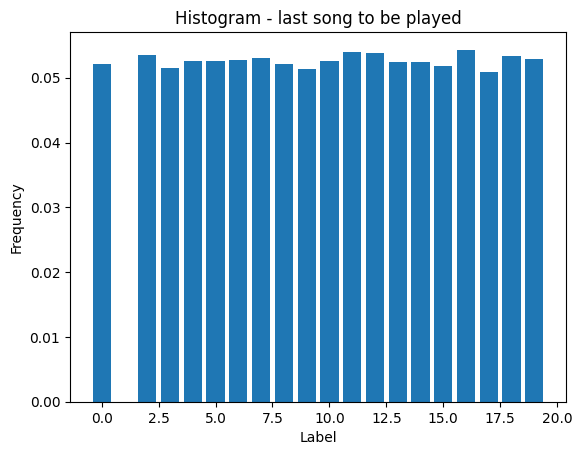

In [ ]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

n = 20
song_1 = 1
trials = 50000
last_songs = []

for _ in range(trials):
    seen = {song_1}
    curr = song_1
    while len(seen) < n:
        move = np.random.choice([-1, 1])
        curr = (curr + move) % n
        if curr not in seen and len(seen) == n-1:
            last_songs.append(curr)
        seen.add(curr)

counts = Counter(last_songs)
songs = list(range(n))
freqs = [counts[s] / trials for s in songs]

plt.bar(songs, freqs)
plt.xlabel("Label")
plt.ylabel("Frequency")
plt.title("Histogram - last song to be played")
plt.show()

<hr><hr>

# Question 2 (The Gambler's Ruin)


In class, we saw the balanced gambler's ruin problem: two gambler's $A$ and $B$ start with $\$a$ and $\$b$ initially, and play a sequence of games, where each game is won by either player with probability $1/2$, with the winner giving $\$ 1$ to the loser. Play goes on till one player runs out of money.

<hr>

**(a)** (5 pts) We argued that when both players have the same initial budget, then each player is equally likely to win. We now want to run a simulation to find a similar formula for general initial budgets. To do so, assume the total budget is $a+b=20$, and run simulations to find the expected probability that $A$ wins for all values of $a$ from $\{0,1,\ldots,20\}$. Plot these, and use this to conjecture what the formula may be.


<hr>

## Ans.

[0.0, 0.04872, 0.09842, 0.15022, 0.19928, 0.24724, 0.29672, 0.34876, 0.40012, 0.44736, 0.50072, 0.5535, 0.59764, 0.64622, 0.70324, 0.75126, 0.79904, 0.85038, 0.89768, 0.95072, 1.0]


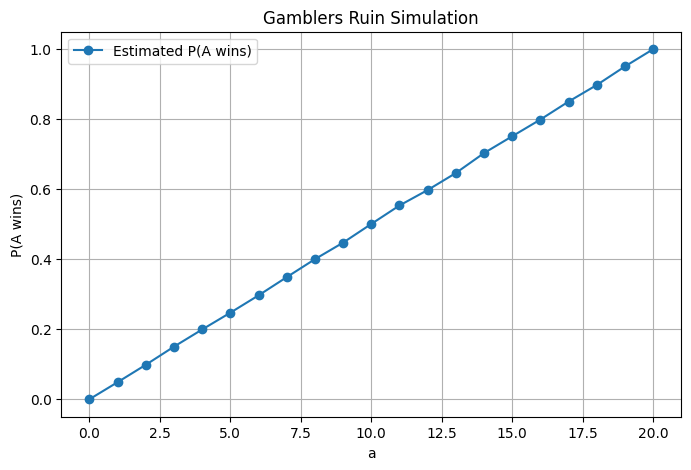

In [ ]:
import random
n = 20
trials = 50000

def simulate(a):
    A = a
    while 0 < A < n:
        if random.random() < 0.5:
            A += 1
        else:
            A -= 1
    return A == n

results = []

for a in range(n + 1):
    wins = 0
    for _ in range(trials):
        if simulate(a):
            wins += 1
    results.append(wins / trials)

print(results)

plt.figure(figsize=(8,5))
plt.plot(range(n+1), results, marker='o', label="Estimated P(A wins)")

plt.xlabel("a")
plt.ylabel("P(A wins)")
plt.title("Gamblers Ruin Simulation")
plt.grid(True)
plt.legend()
plt.show()


The formula appears to be P(A wins) = a/(a+b), which is linear.

**(b)** (10 pts) Another question we can ask is how long it takes for either player to get ruined. To study this, simulate the gambler's ruin for a range of values of $a$ and $b$, and use this to try and guess the expected time to ruin.

Note: Convince yourself that the function must be symmetric in $a$ and $b$, so you can assume $a\leq b$. Try plotting the expected absorption times for selected values of $a$, while varying $b$.


<hr>

## Ans.

In [ ]:
def simulate(a):
    A = a
    t = 0
    while 0 < A < n:
        t += 1
        if random.random() < 0.5:
            A += 1
        else:
            A -= 1
    return A == n, t   # added a var t to return to account for time, assuming symmetry

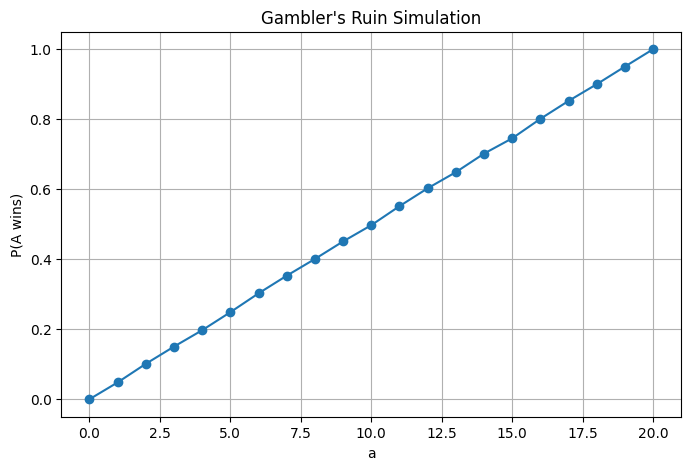

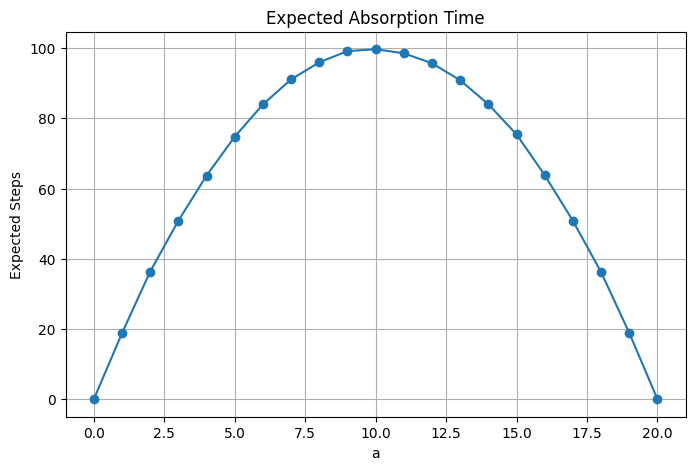

In [ ]:
win_probs = []
exp_times = []

for a in range(n + 1):
    wins = 0
    total_time = 0
    for _ in range(trials):
        win, t = simulate(a)
        if win:
            wins += 1
        total_time += t
    win_probs.append(wins / trials)
    exp_times.append(total_time / trials)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(n+1), win_probs, marker='o')
plt.title("Gambler's Ruin Simulation")
plt.xlabel("a")
plt.ylabel("P(A wins)")
plt.grid(True)
plt.show()

# Absorption Time
plt.figure(figsize=(8,5))
plt.plot(range(n+1), exp_times, marker='o')
plt.title("Expected Absorption Time")
plt.xlabel("a")
plt.ylabel("Expected Steps")
plt.grid(True)
plt.show()


<hr>

**(c)** (OPTIONAL) For parts $(a)$ and $(b)$, try and theoretically prove what you observe from your simulations!


<hr>

## Ans.
a) It makes sense that this is linear and increasing because the formula P(A wins) = a/(a+b) always has a+b=20, and a increases by 1 each time, so testing for all possible values of a and corresponding b values, it takes this form.

b) The absorption time makes sense because at a=0, you are already at an endpoint so time = 0. If you start in the middle, you might take longer to make progress jumping from states, and at the middle itself the distance to either boundary is n/2, which is the peak. The general formula makes sense as E[T] = a(n-a) where T is absorption time at any point.

<hr><hr>

# Question 3 (Staffing a hospital)

**(a)** (5 pts)  Find bounds on the number of receptionists $n_R$, IW beds $N_I$, clinic doctors $d_C$ and ER doctors $d_E$ that the hospital requires to ensure it can keep up with its patient load?

<hr>

## Ans.
$ λ_{E}=5, \lambda_{N}=20.$ Flow to the reception is $\lambda_{R}=20+0.25\lambda_{C}+0.8\lambda_{I}$. $\lambda_{C}=\lambda_{R}$ since all reception patients go to the clinic. $\lambda_{I}=0.1\lambda_{C}+0.5\lambda_{E}$ which can be rewritten as $\lambda_{I}=0.1\lambda_{C}+2.5$. Then, since $\lambda_{C}=\lambda_{R}$, we can rewrite our $\lambda_{R}$ equation as $\lambda_{C}=20+0.25\lambda_{C}+0.8\lambda_{I}$. Then $\lambda_{C}=20+0.25\lambda_{C}+0.8(0.1\lambda_{C}+2.5)=22+0.33\lambda_{C}$  Then solve: $\lambda_{C}-0.33\lambda_{C}=22$ or $0.67\lambda_{C}=22$ so $\lambda_{C}=32.84$ patients per hour. Then $\lambda_{R}= 32.84$ patients per hour and $\lambda_{I}=0.1(32.84)+2.5=5.78$ patients per hour. The reception desk takes 5 minutes on average to admit each patient, or 60/5=12 patients per hour, so $\mu_{R}=12$. We need $n_{R}\mu_{R} > \lambda_{R}$, or $n_{R}12>32.84$ so $n_{R} >2.737$. Therefore, since there cannot be a fraction of receptionists, **$n_{R} \geq 3$**. For IW beds, we know that $\lambda_{I}=5.78$ and that the average stay in the IW is about 72 hours, so on average there are 5.78*72=416.16 patients. Therefore, the number of beds should be $N_{I} \geq 417$. For the clinic doctors, we know that the clinic has an average doctor visit time of 15 minutes or 60/15=4 patients per hour. Since $\lambda_{C}=32.84$. So, $d_{C}\mu_{C} > \lambda_{C}$ or $d_{C}4 > 32.84$ or $d_{C} > 8.21$. Therefore the number of clinic doctors should be $d_{C} \geq 9$. Finally, for ER doctors we know that $\lambda_{E}=5$ and that patients in the ER need one hour with the doctor so $\mu_{E}=1$. So, $d_{E}>5$ so the number of doctorsin the ER is bounded by $d_{E} \geq 6$.


<hr>

**(b)** (10 pts) Suppose the hospital chooses to run with $d_E=7$ doctors in the ER, $d_C=10$ doctors in the clinic, and $n=500$ beds in the IW. Approximate the average time spent in the clinic (including treatment but not including reception) and the average number of busy clinic doctors.

<hr>

## Ans.
From part a, we know $\lambda_{C}=32.84$ and that $\mu_{C}=4$ We are solving a M/M/10 queue so we use an Erlang-C model which we learned in orie 3510 to find the probability that a client waits. $\rho=\lambda_{C}/d{c}\mu_{C} = 32.84/40=0.821$. Let $a=d_{c}*\rho=\lambda_{C}/\mu_{C}=8.21$, which is the load. Therefore on average,8.21 clinic doctors are busy. So $P_w =
\frac{
    \frac{a^c}{c!}\,\frac{c}{\,c-a\,}
}{
    \left( \sum_{n=0}^{c-1} \frac{a^n}{n!} \right)
    +
    \frac{a^c}{c!}\,\frac{c}{\,c-a\,}
}
$ $
P_w =
\frac{
    \dfrac{8.21^{10}}{10!}\,\dfrac{10}{10 - 8.21}
}{
    \ (\sum_{n=0}^{9} \frac{8.21^{n}}{n!})
    \;+\;
    \dfrac{8.21^{10}}{10!}\,\dfrac{10}{10 - 8.21}
}$. The numerator = 2141.980473, and the denominator = 4680.40487382. So $P_{w}=2141.980473/4680.40487382=0.4576$. We then use this to calculate the the average time spent waiting in the clinic: wait = $\frac{P_{w}}{c\mu_{C}-\lambda{C}}=\frac{0.4576}{40-32.84}=0.06391$ hours $= 3.83$ minutes. Then the total time spent in the clinic is $wait + \frac{1}{\mu_{C}}=0.06391+0.25=0.3139$ hours or $18.83$ minutes.

<hr>

**(c)** (10 pts) Suppose the hospital chooses to run with $d_E=7$ doctors in the ER, $d_C=10$ doctors in the clinic, and $n=500$ beds in the IW. Compute the probability that the hospital will simultaneously have no patients in the ER and no patients in the clinic.

<hr>

## Ans.
 For a M/M/c queue, $P_{0}=\left[\sum _{n=0}^{c-1}\frac{(a)^{n}}{n!}+\frac{(a)^{c}}{c!}\frac{c}{c-a }\right]^{-1}$ where $a=\rho*c=\frac{\lambda}{\mu}$. To calculate the probability that there will be no patients in the ER we caculate that $\rho=\lambda_{E}/c\mu_{E}=5/7$ and that $a=\lambda_{E}/\mu_{E}=5/1=5$, as this is a M/M/7 queue. Then $P_{0E}=\left[\sum _{n=0}^{6}\frac{(5)^{n}}{n!}+\frac{(5)^{7}}{7!}\frac{7}{7-5 }\right]^{-1} = 288/48203 = 0.005974$. Then for the probability that there are no patients in the clinic,the denominator of $P_w =
\frac{
    \dfrac{8.21^{10}}{10!}\,\dfrac{10}{10 - 8.21}
}{
    \ (\sum_{n=0}^{9} \frac{8.21^{n}}{n!})
    \;+\;
    \dfrac{8.21^{10}}{10!}\,\dfrac{10}{10 - 8.21}
}$ $=P_{0C}=\left[\sum _{n=0}^{c-1}\frac{(a)^{n}}{n!}+\frac{(a)^{c}}{c!}\frac{c}{c-a }\right]$. We calculated in part b that the denominator is $4680.40487382$. So $=P_{0C}=\left[\sum _{n=0}^{c-1}\frac{(a)^{n}}{n!}+\frac{(a)^{c}}{c!}\frac{c}{c-a }\right]^{-1}=1/4680.4048738=2.136*10^{-4}$ Finally, the probability that the hospital will simultaneously have no patients in the ER and no patients in the clinic is $P(\text{ER & Clinic have no patients})=P_{0E}\times P_{0C}= 0.005974\times2.136\times 10^{-4}=1.276\times 10^{-6}$.

<hr>

**(d)** (40 pts) Build a simulator for the above model, assuming the external arrivals to the reception and ER are Poisson processes, and all service times are exponential and all routings are independent. You can re-use any of the code we provided in the recitations.

Use your simulator to study the following:

$(i)$ Plot the total number of patients waiting in the hospital when the number of doctors and beds is $1$ more than your suggestions in part $(a)$, and when it is $1$ less than your suggestions in part $(a)$. You should simulate over a long enough time horizon to be able to determine whether the numbers stabilize, or grow unbounded.

$(ii)$ Simulate the configuration in part $(b)$, and plot the average time spent by patients in the clinic, and the average number of busy clinic doctors. How do these compare to the answers in part $(b)$?

<hr>

## Ans.

In [ ]:
#helper functions from rec 12

# General class for the entities that move through the Queues
class Entity(object):

    starttime = 0

    # Initialize an Entity
    def __init__(self, start):
        self.starttime = start

    # Print an Entity (just arrival time)
    def __repr__(self):
        return str(self.starttime)

In [ ]:
# General class for the queues themselves
class Queue(object):
    def __init__(self, name, waiting):
        self.name = name
        self.waitingentities = waiting

    def __repr__(self):
        return self.name + ": " + str(self.waitingentities)

    def ArriveatQueue(self, time):
        newarrival = Entity(time)
        self.waitingentities.append(newarrival)

    def LeaveQueue(self):
        newentities = []
        for e in range(1, np.size(self.waitingentities)):
            newentities.append(self.waitingentities[e])
        self.waitingentities = newentities

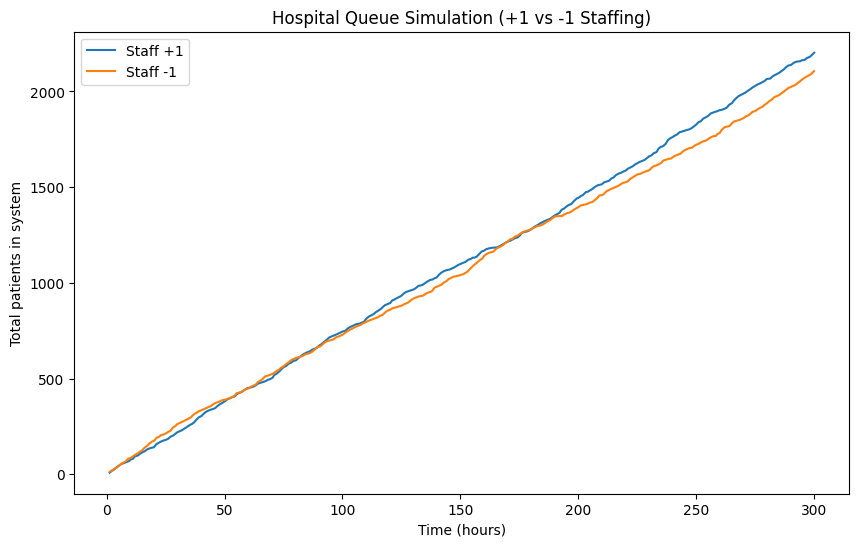

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#help from Claude
# part (i) simluation
lambda_R = 32.84  # reception arrivals per hour
lambda_E = 5.0               # ER arrivals per hour
lambda_I = 5.78  # IW arrivals (from part a, not directly used here)
lambda_C = lambda_R           # all reception patients go to clinic


mu_R = 12.0   # reception: 5 minutes avg
mu_C = 4.0    # clinic doctor: 15 minutes avg
mu_E = 1.0    # ER doctor: 1 hour avg
mu_I = 1.0/72.0

min_R = 3
min_E = 6
min_C = 9
min_I = 417  # for beds

Tmax = 300.0  # hours
dt_record = 1.0

def run_simulation(num_R, num_C, num_E, num_I):
    # Queues
    R = Queue("Reception", [])
    C = Queue("Clinic", [])
    E = Queue("ER", [])
    I = Queue("IW", [])

    busy_R = 0
    busy_C = 0
    busy_E = 0
    busy_I = 0

    t = 0.0

    # Arrivals
    nextarrival_R = np.random.exponential(1.0 / lambda_R)
    nextarrival_E = np.random.exponential(1.0 / lambda_E)

    # Departures
    nextdeparture_R = 1e9
    nextdeparture_C = 1e9
    nextdeparture_E = 1e9
    nextdeparture_I = 1e9

    times = []
    total_patients = []


    while t < Tmax:
        # Find next event
      nevents = np.array([
      nextarrival_R, nextarrival_E,
      nextdeparture_R, nextdeparture_C,
      nextdeparture_E, nextdeparture_I])

      event = np.argmin(nevents)
      t = np.min(nevents)


      if int(t / dt_record) > len(times):
          total = (len(R.waitingentities) + len(C.waitingentities) +
                  len(E.waitingentities) + len(I.waitingentities) +
                  busy_R + busy_C + busy_E + busy_I)
          total_patients.append(total)
          times.append(t)

      if event == 0:
          R.ArriveatQueue(t)
          nextarrival_R += np.random.exponential(1.0 / lambda_R)
          if busy_R < num_R:
              busy_R += 1
              nextdeparture_R = t + np.random.exponential(1.0 / mu_R)


      if event == 1:
          E.ArriveatQueue(t)
          nextarrival_E = t + np.random.exponential(1.0 / lambda_E)

          if busy_E < num_E:
              busy_E += 1
              nextdeparture_E = t + np.random.exponential(1.0 / mu_E)


      if event == 2 and len(R.waitingentities) > 0:
          busy_R -= 1
          R.LeaveQueue()

          if len(R.waitingentities) > 0:
              busy_R += 1
              nextdeparture_R = t + np.random.exponential(1.0 / mu_R)
          else:
              nextdeparture_R = 1e6

          C.ArriveatQueue(t)

          if busy_C < num_C and len(C.waitingentities) > 0:
                busy_C += 1
                nextdeparture_C = t + np.random.exponential(1.0 / mu_C)

      if event == 3 and len(C.waitingentities) > 0:
          busy_C -= 1
          C.LeaveQueue()
          if len(C.waitingentities) > 0:
              busy_C += 1
              nextdeparture_C = t + np.random.exponential(1.0 / mu_C)
          else:
              nextdeparture_C = 1e6
      rand = np.random.rand()
      if rand < 0.25:
        nextarrival_R = t + 504
      elif rand < 0.35 and busy_I < num_I:
        I.ArriveatQueue(t)
        busy_I += 1
        nextdeparture_I = t + np.random.exponential(1.0 / mu_I)

      if event == 4 and len(E.waitingentities) > 0:
            busy_E -= 1
            ent = E.waitingentities[0]
            E.LeaveQueue()
            ent.starttime = t
            C.waitingentities.append(ent)

            if len(E.waitingentities) > 0:
                busy_E += 1
                nextdeparture_E = t + np.random.exponential(1.0 / mu_E)
            else:
                nextdeparture_E = 1e6

            if np.random.rand() < 0.5 and busy_I < num_I:
                I.ArriveatQueue(t)
                busy_I += 1
                nextdeparture_I = t + np.random.exponential(1.0 / mu_I)

      if event == 5 and len(I.waitingentities) > 0:
        busy_I -= 1
        I.LeaveQueue()

        if len(I.waitingentities) > 0:
          busy_I += 1
          nextdeparture_I = t + np.random.exponential(1.0/mu_I)
        else:
          nextdeparture_I =1e6
        if np.random.rand() < 0.8:
          nextarrival_R = t+504



    return times, total_patients

times_plus, patients_plus = run_simulation(min_R+1, min_C+1, min_E+1, min_I+1)
times_minus, patients_minus = run_simulation(min_R-1, min_C-1, min_E-1, min_I-1)

#plot
plt.figure(figsize=(10,6))
plt.plot(times_plus, patients_plus, label="Staff +1")
plt.plot(times_minus, patients_minus, label="Staff -1")
plt.xlabel("Time (hours)")
plt.ylabel("Total patients in system")
plt.title("Hospital Queue Simulation (+1 vs -1 Staffing)")
plt.legend()
plt.show()

Average time in clinic (hours): 106.4086 (~6384.51 minutes)
Average number of busy clinic doctors: 9.97


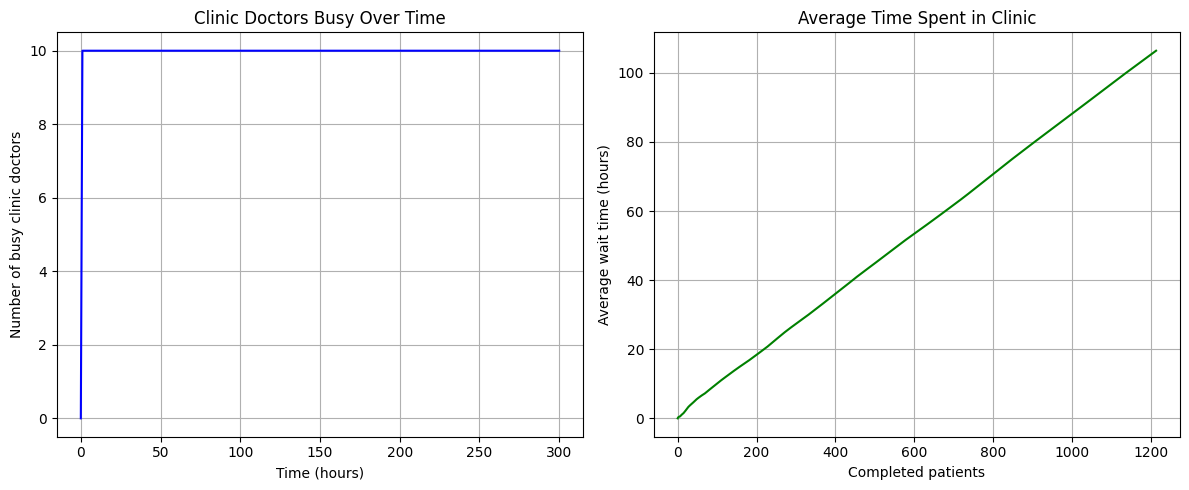

In [ ]:
# part (ii) simulation
#help from Claude because it goes off of part i
lambda_R = 32.8358208955224
lambda_E = 5.0
lambda_C = lambda_R

mu_R = 12.0
mu_C = 4.0
mu_E = 1.0

num_R = 3
num_C = 10
num_E = 7

Tmax = 300.0

def simulate_clinic():
    R = Queue("Reception", [])
    C = Queue("Clinic", [])
    E = Queue("ER", [])

    busy_R = 0
    busy_C = 0
    busy_E = 0

    t = 0.0
    nextarrival_R = np.random.exponential(1.0 / lambda_R)
    nextarrival_E = np.random.exponential(1.0 / lambda_E)
    nextdeparture_R = 1e6
    nextdeparture_C = 1e6
    nextdeparture_E = 1e6

    clinic_times = []
    busy_clinic_history = []
    times = []

    dt_record = 1.0

    while t < Tmax:
        nevents = np.array([nextarrival_R, nextarrival_E, nextdeparture_R, nextdeparture_C, nextdeparture_E])
        event = np.argmin(nevents)
        t = np.min(nevents)

        if event == 0:
            R.ArriveatQueue(t)
            nextarrival_R += np.random.exponential(1.0 / lambda_R)
            if busy_R < num_R:
                busy_R += 1
                nextdeparture_R = t + np.random.exponential(1.0 / mu_R)

        if event == 1:
            E.ArriveatQueue(t)
            nextarrival_E += np.random.exponential(1.0 / lambda_E)
            if busy_E < num_E:
                busy_E += 1
                nextdeparture_E = t + np.random.exponential(1.0 / mu_E)

        if event == 2 and len(R.waitingentities) > 0:
            busy_R -= 1
            ent = R.waitingentities[0]
            R.LeaveQueue()
            ent.starttime = t
            C.waitingentities.append(ent)

            if len(R.waitingentities) > 0:
                busy_R += 1
                nextdeparture_R = t + np.random.exponential(1.0 / mu_R)
            else:
                nextdeparture_R = 1e6

            if busy_C < num_C and len(C.waitingentities) > 0:
                busy_C += 1
                nextdeparture_C = t + np.random.exponential(1.0 / mu_C)

        if event == 3 and len(C.waitingentities) > 0:
            busy_C -= 1
            ent = C.waitingentities[0]
            clinic_times.append(t - ent.starttime)
            C.LeaveQueue()
            if len(C.waitingentities) > 0:
                busy_C += 1
                nextdeparture_C = t + np.random.exponential(1.0 / mu_C)
            else:
                nextdeparture_C = 1e6

        if event == 4 and len(E.waitingentities) > 0:
            busy_E -= 1
            ent = E.waitingentities[0]
            E.LeaveQueue()
            ent.starttime = t
            C.waitingentities.append(ent)
            if busy_C < num_C and len(C.waitingentities) > 0:
                busy_C += 1
                nextdeparture_C = t + np.random.exponential(1.0 / mu_C)
            if len(E.waitingentities) > 0:
                busy_E += 1
                nextdeparture_E = t + np.random.exponential(1.0 / mu_E)
            else:
                nextdeparture_E = 1e6

        if int(t/dt_record) > len(times) - 1:
            busy_clinic_history.append(busy_C)
            times.append(t)

    avg_clinic_time = np.mean(clinic_times)
    avg_busy_clinic = np.mean(busy_clinic_history)
    return avg_clinic_time, avg_busy_clinic, times, busy_clinic_history, clinic_times

avg_time, avg_busy, times, busy_history, clinic_times = simulate_clinic()

print(f"Average time in clinic (hours): {avg_time:.4f} (~{avg_time*60:.2f} minutes)")
print(f"Average number of busy clinic doctors: {avg_busy:.2f}")


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(times, busy_history, color='blue')
plt.xlabel("Time (hours)")
plt.ylabel("Number of busy clinic doctors")
plt.title("Clinic Doctors Busy Over Time")
plt.grid(True)


if len(clinic_times) > 0:
    running_avg_wait = np.cumsum(clinic_times) / np.arange(1, len(clinic_times)+1)
else:
    running_avg_wait = []

plt.subplot(1,2,2)
plt.plot(running_avg_wait, color='green')
plt.xlabel("Completed patients")
plt.ylabel("Average wait time (hours)")
plt.title("Average Time Spent in Clinic")
plt.grid(True)

plt.tight_layout()
plt.show()
